# VCO

## Target spec

source coupled VCO seem simple and easy to tune frequency than ring OSC.
because of tuning simplicity , this VCO just have one capacitor. current for charge/discharge also controlled by current mirror. important point is defining Vth , oscillation voltage is (Vdd-Vth) to (Vdd-3Vth).
frequency of OSC is defined:

Fosc = Id / ( 4 * C * Vth)

| Spec             | Description                              |
|------------------|------------------------------------------|
|  VCO Frequency   | 65-80MHz(FM RADIO 76-90MHz - IF:10.7MHz) |


## Calculate VCO parameter

VCO design parameter:
mim_cap_coefficient_um2:2e-06
mim_cap_capacitance_max:35.00pf
nmos_vth:0.589748V
fosc_max:80000000.0Hz
fosc_min:65000000.0Hz
fosc_range:15000000.0Hz
fosc_upper_lim:81500000.0Hz
fosc_lower_lim:63500000.0Hz
vin_max:2.5V
vin_min:0.8V
--------------------------
VCO design result:
suitable_mim_cap_capacitance:2.36pf
suitable_mim_cap_area_um2:1177.53um^2
suitable_mim_cap_length_um:34.32um
--------------------------
suitable_id_upper:452.78uA
suitable_id_lower:352.78uA
suitable_id_center:402.78uA
--------------------------
gm_vin_to_id:5.88235294117647e-05
suitable_gm_id:0.5882352941176471
suitable_id_offset:402.78uA
--------------------------


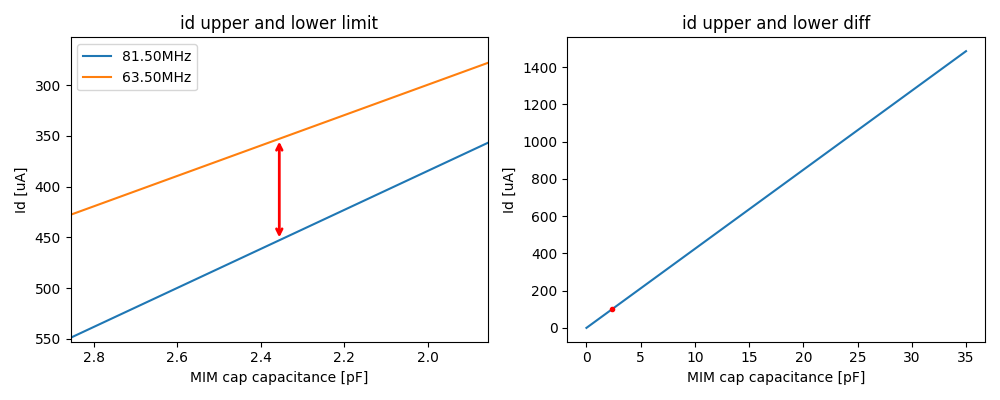

In [33]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import math


# VCO spec and limitation
mim_cap_coefficient_um2 = 2e-6
mim_cap_capacitance_max=35e-12
nmos_vth=0.589748
fosc_max=80e6
fosc_min=65e6
id_diff_uppper_lower=100e-6
vin_max = 2.5
vin_min = 0.8


fosc_range=fosc_max-fosc_min
# Add frequency margin +-10%
fosc_upper_lim=fosc_max+fosc_range*0.1
fosc_lower_lim=fosc_min-fosc_range*0.1

# Calculate suitable mim cap and id current
mim_cap_range = np.linspace(0,mim_cap_capacitance_max,100)
id_upper_lim_range=mim_cap_range*fosc_upper_lim*4*nmos_vth
id_lower_lim_range=mim_cap_range*fosc_lower_lim*4*nmos_vth
id_upper_lower_lim_diff_range=id_upper_lim_range-id_lower_lim_range
f_id_upper_lower_lim_diff_range_to_mim_cap_range = interpolate.interp1d(id_upper_lower_lim_diff_range, mim_cap_range)
suitable_mim_cap_capacitance=f_id_upper_lower_lim_diff_range_to_mim_cap_range(id_diff_uppper_lower)
f_mim_cap_range_to_id_upper_lim_range = interpolate.interp1d(mim_cap_range, id_upper_lim_range)
f_mim_cap_range_to_id_lower_lim_range = interpolate.interp1d(mim_cap_range, id_lower_lim_range)
suitable_id_upper=f_mim_cap_range_to_id_upper_lim_range(suitable_mim_cap_capacitance)
suitable_id_lower=f_mim_cap_range_to_id_lower_lim_range(suitable_mim_cap_capacitance)

# Calculate suitable gm
id_diff = suitable_id_upper - suitable_id_lower
suitable_id_center = suitable_id_lower +  (suitable_id_upper - suitable_id_lower)/2
vin_diff = vin_max-vin_min
gm_vin_to_id = id_diff/vin_diff
suitable_gm_id = gm_vin_to_id/id_diff
suitable_id_offset = suitable_id_center



# Calculate MIM cap area
suitable_mim_cap_area_um2 = suitable_mim_cap_capacitance / mim_cap_coefficient
suitable_mim_cap_length_um = math.sqrt(suitable_mim_cap_area);

# Print design parameter
print("VCO design parameter:")
print(f"mim_cap_coefficient_um2:{mim_cap_coefficient_um2}")
print(f"mim_cap_capacitance_max:{mim_cap_capacitance_max/ 1e-12:.2f}pf")
print(f"nmos_vth:{nmos_vth}V")
print(f"fosc_max:{fosc_max}Hz")
print(f"fosc_min:{fosc_min}Hz")
print(f"fosc_range:{fosc_range}Hz")
print(f"fosc_upper_lim:{fosc_upper_lim}Hz")
print(f"fosc_lower_lim:{fosc_lower_lim}Hz")
print(f"vin_max:{vin_max}V")
print(f"vin_min:{vin_min}V")

print("--------------------------")
print("VCO design result:")
print(f"suitable_mim_cap_capacitance:{suitable_mim_cap_capacitance/ 1e-12:.2f}pf")
print(f"suitable_mim_cap_area_um2:{suitable_mim_cap_area_um2:.2f}um^2")
print(f"suitable_mim_cap_length_um:{suitable_mim_cap_length_um:.2f}um")
print("--------------------------")
print(f"suitable_id_upper:{suitable_id_upper/ 1e-6:.2f}uA")
print(f"suitable_id_lower:{suitable_id_lower/ 1e-6:.2f}uA")
print(f"suitable_id_center:{suitable_id_center/ 1e-6:.2f}uA")
print("--------------------------")
print(f"gm_vin_to_id:{gm_vin_to_id}")
print(f"suitable_gm_id:{suitable_gm_id}")
print(f"suitable_id_offset:{suitable_id_offset/ 1e-6:.2f}uA")
print("--------------------------")


# Plot result
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# 1st chart
axes[0].set_title('id upper and lower limit')
axes[0].set_xlabel("MIM cap capacitance [pF]")
axes[0].set_ylabel("Id [uA]")
axes[0].plot(mim_cap_range/1e-12, id_upper_lim_range/1e-6,label=f"{fosc_upper_lim / 1e6:.2f}MHz")
axes[0].plot(mim_cap_range/1e-12, id_lower_lim_range/1e-6,label=f"{fosc_lower_lim / 1e6:.2f}MHz")
axes[0].legend()
axes[0].annotate("", xy=(suitable_mim_cap_capacitance/1e-12, suitable_id_upper/1e-6), xytext=(suitable_mim_cap_capacitance/1e-12, suitable_id_lower/1e-6),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
axes[0].set_xlim((suitable_mim_cap_capacitance+0.5e-12)/1e-12,(suitable_mim_cap_capacitance-0.5e-12)/1e-12)
axes[0].set_ylim((suitable_id_upper+100e-6)/1e-6,(suitable_id_lower-100e-6)/1e-6)

# 2nd chart
axes[1].set_title('id upper and lower diff')
axes[1].set_xlabel("MIM cap capacitance [pF]")
axes[1].set_ylabel("Id [uA]")
axes[1].plot(mim_cap_range/1e-12, id_upper_lower_lim_diff_range/1e-6)
axes[1].plot(suitable_mim_cap_capacitance/1e-12,id_diff_uppper_lower/1e-6,marker='.',color="red")

plt.tight_layout()
plt.show()